In [93]:
import cv2
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
import segmentation_models_pytorch as smp

In [ ]:
LARS_COLORS = {
    1: (255, 0, 0),  
    3: (0, 0, 255),     
    5: (0, 255, 255),  

    11: (255,255,0),     
    12: (0,255,0),   
    13: (255,0,255),  
    14: (255,165,0),     
    15: (255,69,0),   
    16: (255,192,203),   
    17: (255,215,0),   
    19: (139,0,255), 
}

SEM_COLORS = {
    0: (255, 0, 0),  
    1: (0, 0, 255),     
    2: (0, 255, 255),   
}

INST_COLORS = {
    0: (255,255,0),   
    1: (0,255,0),  
    2: (255,0,255), 
    3: (255,165,0), 
    4: (255,69,0),    
    5: (255,192,203), 
    6: (255,215,0),   
    7: (139,0,255), 
}

In [ ]:
YOLO_TO_PANOPTIC = {
    0: 10,  
    1: 11,  
    2: 12,  
    3: 13,  
    4: 14,  
    5: 15,  
    6: 16,  
    7: 17, 
}

PANOPTIC_COLORS = {
    0: (255, 0, 0),  
    1: (0, 0, 255),     
    2: (0, 255, 255),        

    10: (255,255,0),    
    11: (0,255,0),   
    12: (255,0,255), 
    13: (255,165,0),  
    14: (255,69,0),      
    15: (255,192,203),    
    16: (255,215,0),   
    17: (139,0,255), 
}

In [96]:
yolo_model = YOLO(r"E:\Education\4 course 2 semester\Practice\panoptic_project\runs\best.pt")

deeplab_model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=3
)

deeplab_model.load_state_dict(torch.load(r"E:\Education\4 course 2 semester\Practice\panoptic_project\notebooks\deeplab_lars_5.pth"))
deeplab_model = deeplab_model.cuda()
deeplab_model.eval()

DeepLabV3Plus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequentia

In [97]:
def colorize(mask, palette):
    mask = np.array(mask)

    if mask.ndim == 3:
        mask = mask[..., 0]

    h, w = mask.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)

    for k, color in palette.items():
        if k == -1:
            continue
        out[mask == k] = color

    return out

In [98]:
def overlay(image, mask_viz, alpha=0.5):
    image = image.copy().astype(np.float32)
    mask_viz = mask_viz.astype(np.float32)

    out = image * alpha + mask_viz * (1 - alpha)
    return out.astype(np.uint8)

In [99]:
TARGET_SIZE_DEEPLAB = (1024, 1024)
TARGET_SIZE_YOLO = (640, 640)

In [100]:
def preprocess_deeplab(img):
    h, w = img.shape[:2]
    img_640 = cv2.resize(img, TARGET_SIZE_DEEPLAB)
    return img, img_640, (h, w)

In [101]:
def preprocess_yolo(img):
    h, w = img.shape[:2]
    img_1024 = cv2.resize(img, TARGET_SIZE_YOLO)
    return img, img_1024, (h, w)

In [102]:
def run_deeplab(img_640):
    x = torch.from_numpy(img_640).float() / 255.0
    x = x.permute(2,0,1).unsqueeze(0).cuda()

    with torch.no_grad():
        out = deeplab_model(x)

    mask = torch.argmax(out, dim=1)[0].cpu().numpy()
    return mask

In [103]:
def run_yolo(img_1024, original_shape):
    h0, w0 = original_shape

    res = yolo_model(img_1024)[0]
    inst = np.zeros(TARGET_SIZE_YOLO, dtype=np.int32)

    if res.masks is None:
        return inst

    masks = res.masks.data.cpu().numpy()
    cls = res.boxes.cls.cpu().numpy().astype(int)

    for i in range(len(masks)):
        m = cv2.resize(masks[i], TARGET_SIZE_YOLO) > 0.5
        inst[m] = YOLO_TO_PANOPTIC[cls[i]]

    return inst

In [104]:
def resize_back(mask, shape):
    return cv2.resize(mask.astype(np.uint8),
                      (shape[1], shape[0]),
                      interpolation=cv2.INTER_NEAREST)

In [105]:
def load_gt_panoptic(path):
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE)

def load_gt_semantic(path):
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE)

def yolo_txt_to_mask(txt_path, img_shape):
    h, w = img_shape[:2]

    mask = np.zeros((h, w), dtype=np.int32)
    mask = np.full_like(mask, -1)

    if not os.path.exists(txt_path):
        return mask

    with open(txt_path, "r") as f:
        lines = f.readlines()

    for obj_id, line in enumerate(lines):
        parts = list(map(float, line.strip().split()))
        cls = int(parts[0])
        coords = parts[1:]

        pts = np.array(coords).reshape(-1, 2)

        pts[:, 0] *= w
        pts[:, 1] *= h
        pts = pts.astype(np.int32)

        cv2.fillPoly(mask, [pts], cls)

    return mask

In [106]:
def fuse(semantic, instance):
    return np.where(instance > 0, instance, semantic)

In [107]:
def visualize_all(img_path,
                  gt_pan_path,
                  gt_sem_path,
                  gt_inst_path):

    img_orig = cv2.imread(img_path)
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)


    img_deeplab = cv2.resize(img_orig, TARGET_SIZE_DEEPLAB)
    img_yolo = cv2.resize(img_orig, TARGET_SIZE_YOLO)


    h, w = img_orig.shape[:2]


    gt_pan = load_gt_panoptic(gt_pan_path)
    gt_sem = load_gt_semantic(gt_sem_path)
    gt_inst = yolo_txt_to_mask(gt_inst_path, img_orig.shape)


    sem_640 = run_deeplab(img_deeplab)
    inst_1024 = run_yolo(img_yolo, (h, w))


    sem = resize_back(sem_640, (h, w))
    inst = resize_back(inst_1024, (h, w))
    fused_model = fuse(sem, inst)
    fused = resize_back(fused_model, (h, w))


    gt_pan_v = colorize(gt_pan, LARS_COLORS)
    gt_sem_v = colorize(gt_sem, SEM_COLORS)
    gt_inst_v = colorize(gt_inst, INST_COLORS)


    sem_v = colorize(sem, SEM_COLORS)
    inst_v = colorize(inst, PANOPTIC_COLORS)
    fused_v = colorize(fused, PANOPTIC_COLORS)


    fig, ax = plt.subplots(7, 2, figsize=(12, 20))

    ax[0,0].imshow(img_orig)
    ax[0,0].set_title("Input")
    ax[0,0].axis("off")

    # ax[0, 1].imshow(img_orig)
    # ax[0, 1].set_title("Input Overlay")
    # ax[0, 1].axis("off")

    ax[0,1].axis("off")
    ax[0,1].axis("off")
    ax[0,1].axis("off")

    ax[1,0].imshow(gt_pan_v)
    ax[1,0].set_title("GT Panoptic")
    ax[1,0].axis("off")

    ax[1,1].imshow(overlay(img_orig, gt_pan_v))
    ax[1,1].set_title("GT Panoptic Overlay")
    ax[1,1].axis("off")

    ax[2,0].imshow(gt_sem_v)
    ax[2,0].set_title("GT Semantic")
    ax[2,0].axis("off")

    ax[2,1].imshow(overlay(img_orig, gt_sem_v))
    ax[2,1].set_title("GT Semantic Overlay")
    ax[2,1].axis("off")

    ax[3,0].imshow(gt_inst_v)
    ax[3,0].set_title("GT Instance")
    ax[3,0].axis("off")

    ax[3,1].imshow(overlay(img_orig, gt_inst_v))
    ax[3,1].set_title("GT Instance Overlay")
    ax[3,1].axis("off")

    ax[4,0].imshow(sem_v)
    ax[4,0].set_title("DeepLab")
    ax[4,0].axis("off")

    ax[4,1].imshow(overlay(img_orig, sem_v))
    ax[4,1].set_title("GT DeepLab Overlay")
    ax[4,1].axis("off")

    ax[5,0].imshow(inst_v)
    ax[5,0].set_title("GT Yolo")
    ax[5,0].axis("off")

    ax[5,1].imshow(overlay(img_orig, inst_v))
    ax[5,1].set_title("GT Yolo Overlay")
    ax[5,1].axis("off")

    ax[6,0].imshow(fused_v)
    ax[6,0].set_title("Fusion")
    ax[6,0].axis("off")

    ax[6,1].imshow(overlay(img_orig, fused_v))
    ax[6,1].set_title("Fusion Overlay")
    ax[6,1].axis("off")

    plt.tight_layout()
    plt.show()


0: 1024x1024 2 boats, 1 buoy, 83.0ms
Speed: 131.2ms preprocess, 83.0ms inference, 1.9ms postprocess per image at shape (1, 3, 1024, 1024)


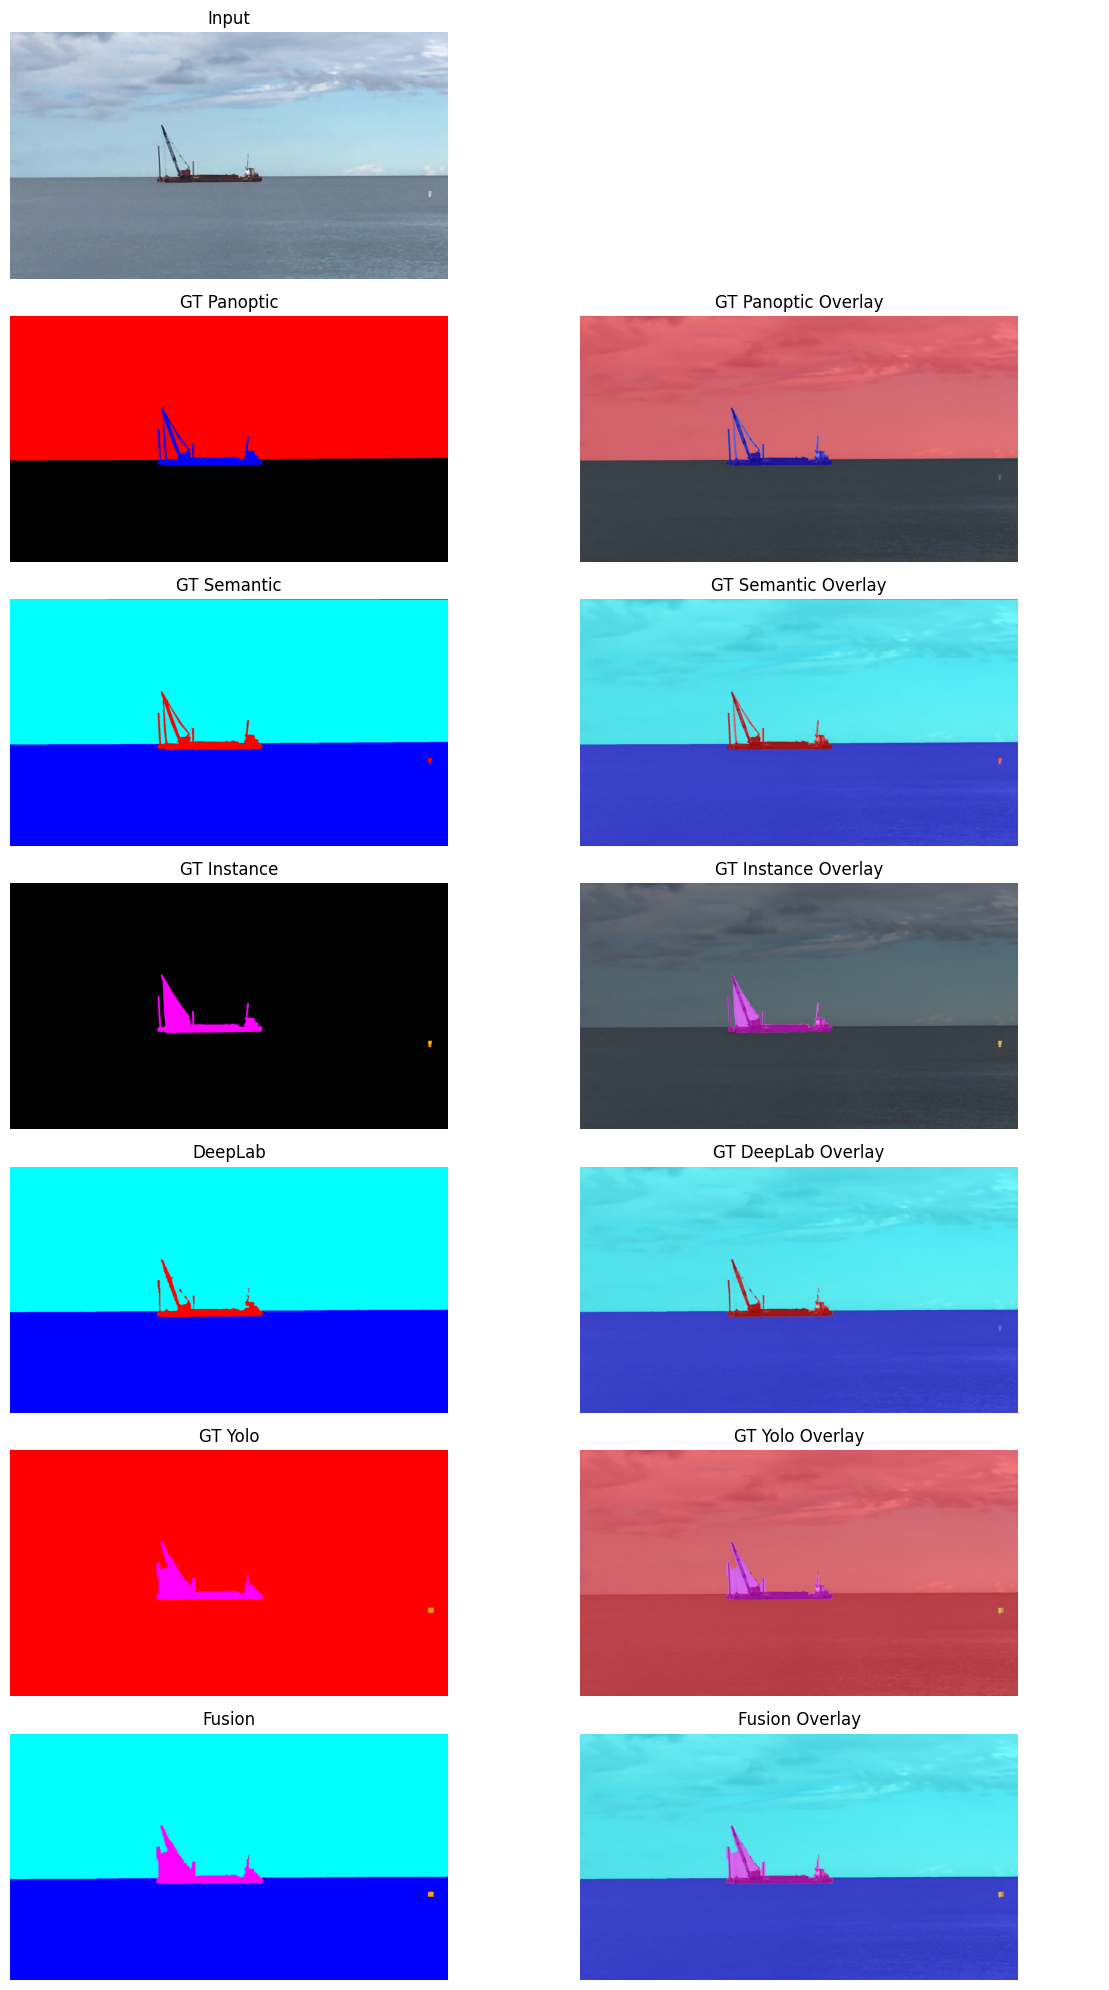

In [108]:
filename = "inhouse_seq_131_00259"

visualize_all(img_path=f"E:/Education/4 course 2 semester/Practice/panoptic_project/Data/lars_converted/semantic/val/images/{filename}.jpg",
                   gt_pan_path=f"E:/Education/4 course 2 semester/Practice/panoptic_project/Data/Lars/annotations/val/panoptic_masks/{filename}.png",
                   gt_sem_path=f"E:/Education/4 course 2 semester/Practice/panoptic_project/Data/lars_converted/semantic/val/masks/{filename}.png",
                   gt_inst_path=f"E:/Education/4 course 2 semester/Practice/panoptic_project/Data/lars_converted/yolo/val/labels/{filename}.txt")